In [239]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy import stats
from scipy.stats import ttest_rel

In [240]:
RUNS = {
    # "143": 
    # {
    #     "folder": '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/02_02_11_51_trial_143',
    #     "color": 'green'
    # },
    # "143 noFbStim": 
    # {
    #     "folder": '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/02_03_08_45_trial_143_NoFbStim',
    #     "color": 'orange'
    # },
    # "143 no fb": 
    # {
    #     "folder": '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/02_03_09_29_trial_143_NoFb',
    #     "color": 'red'
    # },    
    # "random":
    # {
    #     "folder": '/Users/juliuswuerzler/Desktop/2Pong/ImportantRuns/IS_RandomControl',
    #     "color": 'gray'
    # },
    # "209": 
    # {
    #     "folder": '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/02_03_22_18_trial_209',
    #     "color": 'orchid'
    # },
    # "209 RST": 
    # {
    #     "folder": '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/02_04_12_45_209_RST',
    #     "color": 'gray'
    # },
    # "209 no fb":
    # {
    #     "folder": '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/02_04_14_41_trial_8in_6ps_600_nR_02MR_fd',
    #     "color": 'darkgreen'
    # }, 
    # "CP": 
    # {
    #     "folder": '/Users/juliuswuerzler/Desktop/2Pong/New/Search/02_04_22_58_trial_clean_params',
    #     "color": 'red'
    # },
    # "CP 450": 
    # {
    #     "folder": '/Users/juliuswuerzler/Desktop/2Pong/New/Search/02_04_22_56_trial_CP_450',
    #     "color": 'blue'
    # },
    
    # "NT": 
    # {
    #     "folder": '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/02_07_23_59_trial_NT',
    #     "color": 'blue'
    # },
    
    # "CP NT No fb": 
    # {
    #     "folder": '/Users/juliuswuerzler/Desktop/2Pong/New/Search_NewTrace/NT/02_11_20_02_trial_NT_OLDTP_CHECK_NOFB',
    #     "color": 'coral'
    # },
    # "no fb":
    # {
    #     'folder': '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/02_11_10_30_trial_NT_Var0_025_LR1e-3',
    #     'color': 'navy'
    # },
    # "CP NT": 
    # {
    #     "folder": '/Users/juliuswuerzler/Desktop/2Pong/New/Search_NewTrace/NT/02_11_15_02_trial_NT_OLDTP_CHECK',
    #     "color": 'navy'
    # },
    # "304":
    # {
    #     "folder": '/Users/juliuswuerzler/Desktop/2Pong/New/Search/02_04_11_30_trial_304',
    #     "color": 'blue'
    # },
    
   
#     "400 ano 02M 4ps":
#     {
#         'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/8Pong/01_27_20_54_trial_8in_4ps_Allno_400_nR_0_2M_fd',
#         'color': 'blue'
#     },
    # "Baseline no fb":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_12_03_04_trial_NT_OLDTP_NoFB',
    #     'color': 'orchid'
    # },
    # "300s Var02":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_12_03_03_trial_NT_OLDTP_Var02_300s_30Hz',
    #     'color': 'blue'
    # },
    # "No feedback": 
    # {
    #     "folder": '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_12_20_51_trial_NT_OLDTP_Var02_300s_30Hz_yEnc_NoFB',
    #     "color": 'blue'
    # },
    # "Feedback": 
    # {
    #     "folder": '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_12_18_26_trial_NT_OLDTP_Var02_300s_30Hz_yEnc',
    #     "color": 'orange'
    # },
    # "RST FB":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_13_00_38_trial_NT_OLDTP_Var02_300s_30Hz_yEnc_ONLYRSTFB',
    #     'color': 'gray'
    # },
    # "Var 0.001":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_13_18_34_trial_NT_OLDTP_Var0001_300s_30Hz_yEnc',
    #     'color': 'orchid'
    # },
    # "1 Conn":
    # {
    #     'folder': '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/02_14_01_09_trial_NT_OLDTP_Var02_300s_30Hz_yEnc_Ex1Conn',
    #     'color': 'red'
    # },
    # # "2 Inputs":
    # # {
    # #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/BASELINE_2Pong',
    # #     'color': 'blue'
    # # },
    # "8":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/8Pong/01_21_15_50_trial_-1_1ConnMin',
    #     'color': 'dodgerblue'
    # },
    # "8 (bern.)":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/8Pong/01_21_17_56_trial_-1_OnlyRandomConn',
    #     'color': 'limegreen'
    # },
    # "New 2 Params":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_14_11_00_trial_NT_OLDTP_Var0_01_500s_30Hz_yEnc_2PongBaselineParams',
    #     'color': 'black'
    # },
    # "New 2 Params 5RO":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_14_15_48_trial_NT_OLDTP_Var0_01_500s_30Hz_yEnc_2PongBaselineParams_RO5',
    #     'color': 'darkorchid'
    # },
    #     "New 2 Params nofb":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_16_12_15_trial_NT_OLDTP_yEnc_NoFB',
    #     'color': 'red'
    # },
    # "New 2 Params only rstfb":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_16_12_16_trial_NT_OLDTP_yEnc_ONLYRSTFB',
    #     'color': 'blue'
    # },
    # "90s":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_16_16_41_trial_NT_OLDTP_yEnc_90s',
    #     'color': 'navy'
    # },
    # "180s":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_16_16_41_trial_NT_OLDTP_yEnc_180s',
    #     'color': 'orchid'
    # },
    # "45s":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_16_20_03_trial_NT_OLDTP_yEnc_45s',
    #     'color': 'magenta'
    # },
    # "15s":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_16_20_04_trial_NT_OLDTP_yEnc_15s',
    #     'color': 'green'
    # },
    # "RWS Var0":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_17_10_41_trial_NT_OLDTP_yEnc_RANDWS_Var0',
    #     'color': 'magenta'
    # },
    # "RWS Var0 nofb":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_17_10_41_trial_NT_OLDTP_yEnc_RANDWS_Var0_NoFB',
    #     'color': 'red'
    # },
    # "RWS Var02":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_17_16_23_trial_NT_OLDTP_yEnc_RANDWS_Var02_300s',
    #     'color': 'blue'
    # },
    # "RWS Var01 180s":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_17_19_02_trial_NT_OLDTP_yEnc_RANDWS_Var01_180s',
    #     'color': 'coral'
    # },
    # "RWS Var01 15s":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_17_21_33_trial_NT_OLDTP_yEnc_RANDWS_Var01_15s',
    #     'color': 'dodgerblue'
    #     },
    # "RWS Var005 15s":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_17_21_34_trial_NT_OLDTP_yEnc_RANDWS_Var005_15s',
    #     'color': 'black'
    # },
    # "BL V0.025 15s":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_13_23_21_trial_NT_OLDTP_Var0_025_15s_30Hz_yEnc',
    #     'color': 'navy'
    # },
    # "WS V0.025 15s":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_18_15_46_trial_NT_OLDTP_yEnc_RANDWS_Var0025_15s',
    #     'color': 'lime'
    # },
    # "WS V0.025 15s RO01":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_19_00_13_trial_NT_OLDTP_yEnc_RANDWS_Var0025_15s_RO01',
    #     'color': 'brown'
    # },
    # "WS V0.025 15s RO0075":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_19_00_14_trial_NT_OLDTP_yEnc_RANDWS_Var0025_15s_RO0075',
    #     'color': 'red'
    # },
    # "WS V0.025 15s RO-1":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_19_08_33_trial_NT_OLDTP_yEnc_RANDWS_Var0025_15s_ROFUll',
    #     'color': 'orchid'
    # },
    
    
    # "Baseline":
    # {
    #     'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/THESIS/02_12_18_26_trial_NT_OLDTP_Var02_300s_30Hz_yEnc',
    #     'color': 'darkgreen'
    # },
    
    
    "V0.05 30s !fb-S":
    {
        'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_19_21_34_trial_NT_OLDTP_Var0_05_30s_RO01_NoFB-S',
        'color': 'purple'
    },
    "V0.05 30s RO1":
    {
        'folder': '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/02_19_18_42_trial_NT_OLDTP_yEnc_RANDWS_Var005_30s_RO_01',
        'color': 'red'
    },
    "V0.05 !fb":
    {
        'folder': '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/02_19_20_22_trial_NT_OLDTP_Var0_05_30s_RO01_NoFB',
        'color': 'orange'
    },
    
}

In [241]:
def ema(x, alpha=0.2):
    y = np.zeros_like(x, dtype=float)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i-1]
    return y

In [242]:
ALPHA = 0.05
N = 50

for run in RUNS:
    result_files = glob.glob(os.path.join(RUNS[run]['folder'], "*results.csv"))
    RUNS[run]['results'] = {}
    
    
    rolling_means = []
    ss = []
    es = []
    
    for f in result_files:
        network = f.split('_')[-2:-1][0]
        
        if int(network) < 40:
            continue
                
        results = np.loadtxt(f)
        
        RUNS[run]['results'][network] = {}
        
        # get smoothed values
        smoothed_results = ema(results, ALPHA)
        RUNS[run]['results'][network]['rolling means'] = smoothed_results
        rolling_means.append(smoothed_results)
        
        # get start and end
        start_results = np.mean(results[:N])
        end_results = np.mean(results[-N:])
        RUNS[run]['results'][network]['s'] = start_results
        RUNS[run]['results'][network]['e'] = end_results
        ss.append(start_results)
        es.append(end_results)
        
    RUNS[run]['rolling means'] = np.array(rolling_means)
    RUNS[run]['start'] = np.array(ss)
    RUNS[run]['end'] = np.array(es)

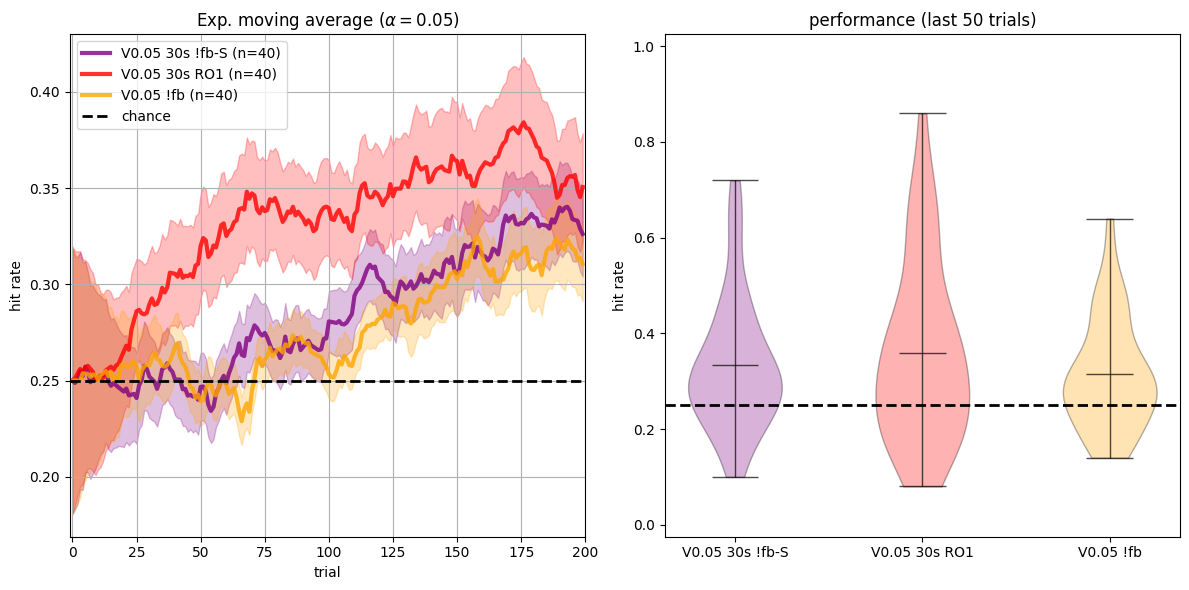

In [243]:
fig, axs = plt.subplots(1,2, figsize=(12,6), sharey=False)


for i, run in enumerate(RUNS):
    
    data = RUNS[run]['rolling means']
    color = RUNS[run]['color']
    
    # Mean and SEM across networks
    _mean = data.mean(axis=0)
    sem = data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])

    x = np.arange(len(_mean))

    # Plot mean
    axs[0].plot(x, _mean, color=color, alpha=0.8, linewidth=3, label=f'{run} (n={len(data)})')

    # Plot SEM as shaded region
    axs[0].fill_between(
        x,
        _mean - sem,
        _mean + sem,
        color=color,
        alpha=0.25,
    )
    
    # plot end performances
    violin_parts = axs[1].violinplot(
        RUNS[run]['end'],
        positions=[i],
        showmeans=True,
        showextrema=True,
        widths=0.5,
        showmedians=False
    )
    # Apply colors
    for body in violin_parts['bodies']:
        body.set_facecolor(color)
        body.set_edgecolor('black')
        # body.set_alpha(0.6)
    for partname in ('cmeans', 'cbars', 'cmins', 'cmaxes', 'cmedians'):
        if partname in violin_parts:
            violin_parts[partname].set_color('black')
            violin_parts[partname].set_linewidth(1)
            violin_parts[partname].set_alpha(0.7)
    
    
axs[0].axhline(0.25, linestyle='--', color='black', linewidth=2, label='chance')
axs[1].axhline(0.25, linestyle='--', color='black', linewidth=2, label='chance')
axs[0].set_title(fr'Exp. moving average ($\alpha=${ALPHA})')
axs[0].set_ylabel('hit rate')
axs[0].set_xlabel('trial')
axs[0].legend()
axs[1].set_ylim([-0.025,1.025])
# axs[0].set_ylim([0.125,0.525])

axs[1].set_xticks(np.arange(len(RUNS)))
axs[1].set_xticklabels([run for run in RUNS])
axs[1].set_ylabel('hit rate')
axs[1].set_title(f'performance (last {N} trials)')

axs[0].grid(True)

axs[0].set_xlim([-1,200])

# axs[1].axhline(0.25*1.4)


plt.tight_layout()
plt.show()


In [244]:
# s_acc = np.zeros(len(result_files))
# e_acc = np.zeros_like(s_acc)

# rolling_means = []
# decreasing_runs = []

# for i, network in enumerate(sorted(all_results.keys(), key=int)):
#     s_acc[i] = np.mean(all_results[network]['results'][:N])
#     e_acc[i] = np.mean(all_results[network]['results'][-N:])
    
#     if e_acc[i] < s_acc[i] - 0.1: 
#         decreasing_runs.append((network, s_acc[i], e_acc[i], e_acc[i] - s_acc[i]))
    
# print(len(all_results))

0.062


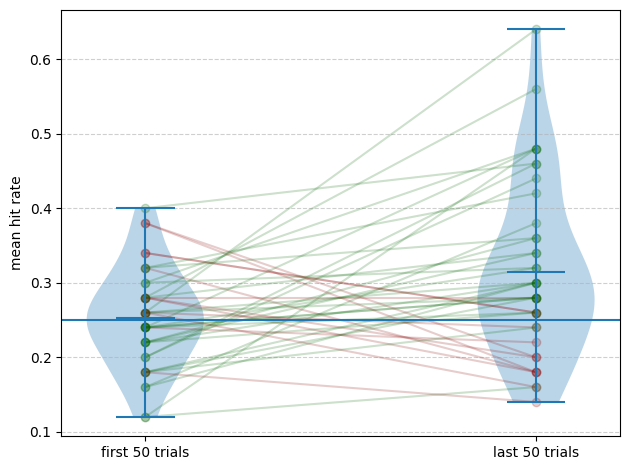

In [245]:
run = 'V0.05 !fb'

s_acc = RUNS[run]['start']
e_acc = RUNS[run]['end']

for i, (s, e) in enumerate(zip(s_acc, e_acc)):
    color = 'darkgreen' if e > s else 'darkred'
    alpha = 0.2 if e > s else 0.2
    plt.plot([0, 1], [s, e], marker='o', linestyle='-', alpha=alpha, color=color)
    

plt.violinplot([s_acc, e_acc], 
               positions=[0,1],
               showmeans=True, 
               # showmedians=True,
               showextrema=True, 
               widths=0.3)

print(np.mean(e_acc) - np.mean(s_acc))

plt.xticks([0, 1], [f'first {N} trials', f'last {N} trials'])
plt.ylabel('mean hit rate')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.axhline(0.25)

plt.tight_layout()
plt.show()

In [246]:
print(f"{np.mean(s_acc):.3f}")
print(f"{np.mean(e_acc):.3f}")
print(f"{np.mean(e_acc - s_acc):.3f}")

0.253
0.315
0.062


In [247]:
from scipy.stats import shapiro

diff = e_acc - s_acc
shapiro(diff)

ShapiroResult(statistic=np.float64(0.9732362222433175), pvalue=np.float64(0.45284629596377884))

In [248]:
from scipy.stats import ttest_rel

t_stat, p_val = ttest_rel(s_acc, e_acc)
print("t =", t_stat, "p =", p_val)

t = -2.8894766858261245 p = 0.006271312864805916


In [249]:
s = np.asarray(s_acc, dtype=float)
e = np.asarray(e_acc, dtype=float)
if s.shape != e.shape:
    raise ValueError(f"Shape mismatch: s_acc {s.shape} vs e_acc {e.shape}")

# Per-seed improvement (end - start)
d = e - s
n = d.size
df = n - 1

mean_s = s.mean()
mean_e = e.mean()
mean_diff = d.mean()
sd_diff = d.std(ddof=1)
se_diff = sd_diff / np.sqrt(n)

# Paired t-test
# Two-sided (default)
t_stat_2s, p_val_2s = ttest_rel(e, s)  # tests mean(e - s) != 0

# One-sided p-value for "improved" (mean(e - s) > 0)
# (Works regardless of SciPy version)
p_val_1s = p_val_2s / 2 if t_stat_2s > 0 else 1 - (p_val_2s / 2)

# 95% CI for mean improvement (two-sided)
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha / 2, df=df)
ci_low = mean_diff - t_crit * se_diff
ci_high = mean_diff + t_crit * se_diff

# Effect size: Cohen's d for paired samples (a.k.a. dz)
# dz = mean(diff) / sd(diff)
cohens_dz = mean_diff / sd_diff if sd_diff > 0 else np.inf

# Optional: Hedges' g correction for small n (paired analogue)
J = 1 - (3 / (4 * df - 1)) if df > 1 else 1.0
hedges_gz = J * cohens_dz

print("Paired comparison (per seed): end - start")
print(f"n = {n}")
print(f"start: mean = {mean_s:.6f}, end: mean = {mean_e:.6f}")
print(f"diff (end-start): mean = {mean_diff:.6f}, sd = {sd_diff:.6f}, se = {se_diff:.6f}")
print(f"t({df}) = {t_stat_2s:.6f}")
print(f"p (two-sided) = {p_val_2s:.6g}")
print(f"p (one-sided, improved) = {p_val_1s:.6g}")
print(f"95% CI for mean diff = [{ci_low:.6f}, {ci_high:.6f}]")
print(f"Cohen's dz = {cohens_dz:.6f}")
print(f"Hedges' gz (small-sample corrected) = {hedges_gz:.6f}")

Paired comparison (per seed): end - start
n = 40
start: mean = 0.252500, end: mean = 0.314500
diff (end-start): mean = 0.062000, sd = 0.135707, se = 0.021457
t(39) = 2.889477
p (two-sided) = 0.00627131
p (one-sided, improved) = 0.00313566
95% CI for mean diff = [0.018599, 0.105401]
Cohen's dz = 0.456866
Hedges' gz (small-sample corrected) = 0.448024


In [250]:
from scipy.stats import wilcoxon

w, p = wilcoxon(s_acc, e_acc)
print("W =", w, "p =", p)


W = 204.0 p = 0.009412288043209864
